In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, dm, aefc, pwp, shmim_utils, coro_utils, telem
import lina.control_models as cmods

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 0.307

dm_mask = dm.create_mask(Nact=34, return_np=1)
utils.imshow([dm_mask])

/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
ERROR:purepyindi:Connection refused: [Errno 111] Connection refused


ConnectionRefusedError: [Errno 111] Connection refused

In [ ]:
data_path = Path(f'../data/{today}-aefc')
telem.make_dir(data_path)

Directory '../data/20251204-iefc-2' created successfully.


In [ ]:
reload(cmods)
M = cmods.MODEL(
    wavelength_c=633e-9,
    npix=250, Ndef=252, N_vortex_lres=1024,
    vortex_win_diam=25, # diameter of the Tukey window in lambda/D to apply for the vortex model 
    vortex_hres_sampling=0.05, # lam/D per pixel; this value is chosen empirically
    vortex_dot_mask_diam_lamDc=0.85,
    dm_beam_diam = 9.2e-3,
    lyot_beam_diam=9.2e-3,
    lyot_diam=8.6e-3,
    # exit_pupil_prop_dist=200e-3,
    camsci_pxscl_lamDc=0.307,
    ncamsci=256,
    Nact=34,
    act_spacing=300e-6,
    act_coupling=0.15,
    # PREFPM_AMP=wfe_data['PREFPM_AMP'],
    # PREFPM_OPD=wfe_data['PREFPM_OPD'],
)

actuators = np.zeros(M.Nacts)
ref_psf = xp.abs(M.forward(actuators, wavelength=M.wavelength_c, use_vortex=False))**2
M.Imax_ref = xp.max(ref_psf)
coro_im = xp.abs(M.forward(actuators, wavelength=M.wavelength_c, plot=1))**2

iwa = 3
owa = 10

annular_dh_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci,
    M.camsci_pxscl_lamDc,
    iwa, 
    owa,  
    edge=iwa,
    centering='odd', # odd or even
    rotation=90,
    x_shift=0,
    y_shift=0,
    return_np=1,
)

model_based_contrast = xp.mean(coro_im[xp.array(annular_dh_mask)])
print(model_based_contrast)

utils.imshow(
    [ref_psf/M.Imax_ref, coro_im, annular_dh_mask],
    norms=[LogNorm(1e-6), LogNorm(1e-8)],
)

# Connect and initialize the hardware.

In [2]:
reload(coro_utils)

camsci_channel = 'camsci'
dm_channel = 'dm00disp01'

xc, yc = (4580, 2110)
ncamsci = 256
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

coro_utils.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel)
coro_utils.set_cam_exp_time(0.001, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)
coro_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 2.0


In [6]:
reload(coro_utils)
coro_utils.set_fiber_atten(0, client0)

Set the fiber attenuation to 0.0


In [3]:
reload(coro_utils)
coro_utils.home_block(client0, delay=2.0)

In [4]:
coro_utils.move_block_out(client0)

In [16]:
reload(coro_utils)
coro_utils.move_psf(-10, 0, client0)

In [5]:
reload(coro_utils)
coro_utils.move_psf(0, -10, client0)

In [ ]:
CAMSCI_STREAM = ImageStream(camsci_channel)
DM_STREAM = ImageStream(dm_channel)

# Do the normalization

In [170]:
coro_utils.move_psf(-50, 0, client0)

In [174]:
coro_utils.move_psf(0, -50, client0)

In [167]:
reload(coro_utils)
coro_utils.set_fiber_atten(35, client)
coro_utils.set_cam_exp_time(0.0005, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)


Set the fiber attenuation to 35.0
Set the camsci exposure time to 5.00e-04s
Set the camsci gain setting to 120.0


In [177]:
reload(coro_utils)
coro_utils.move_block_in(client0)

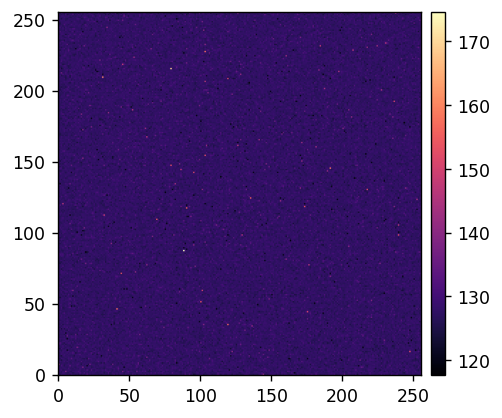

In [180]:
reload(shmim_utils)
dark_im = shmim_utils.stack(CAMSCI_STREAM, 500)
# utils.save_pickle(iefc_data_path/f'{today}_camsci_dark_frame_{im_params["texp"]:.6f}.pkl', dark_frame)

utils.imshow([dark_im])

In [181]:
reload(coro_utils)
coro_utils.move_block_out(client0)

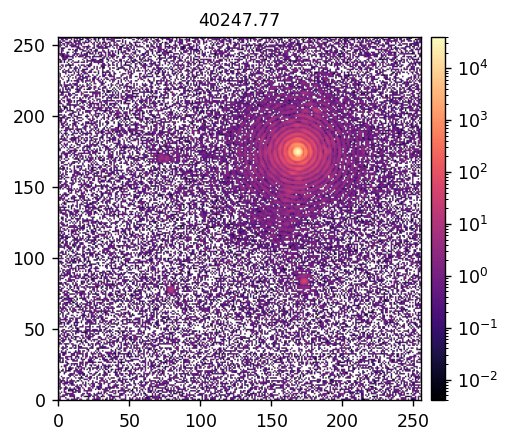

In [183]:
reload(coro_utils)
ref_psf = shmim_utils.stack(CAMSCI_STREAM, 200) - dark_im
Imax_ref = np.max(ref_psf)
utils.imshow([ref_psf], titles=[f'{Imax_ref:.2f}'], norms=[LogNorm()])


In [ ]:
reload(coro_utils)
ref_psf_params = coro_utils.get_im_params(client0, client, cam_name=camsci_channel)
ref_psf_params.update({
    'Imax': Imax_ref,
})
# ref_psf_params = {
#     'Imax': Imax_ref,
#     'exp_time': coro_utils.get_cam_exp_time(client0, camsci_channel), 
#     'gain': coro_utils.get_cam_gain(client0, camsci_channel),
#     'atten': coro_utils.get_fiber_atten(client),
# }
# utils.save_pickle(iefc_data_path/f'{today}_ref_psf_params.pkl', ref_psf_params)

# ref_psf_params = utils.load_pickle(data_path/f'{today}_ref_psf_params.pkl')

print(ref_psf_params)

{'Imax': np.float64(40247.772), 'exp_time': 0.000500000023748726, 'gain': 120.0, 'atten': 35.0}


# Move back onto the vortex and adjust exposure times

In [192]:
coro_utils.move_psf(20, 0, client0)

In [191]:
coro_utils.move_psf(0, 20, client0)

In [210]:
coro_utils.move_psf(-1, 0, client0, delay=1.0)

In [207]:
# reload(coro_utils)
coro_utils.move_psf(0, -1, client0, delay=1.0)

In [ ]:
coro_utils.set_fiber_atten(0, client)
coro_utils.set_cam_exp_time(0.0005, client0, cam_name=camsci_channel)
coro_utils.set_cam_gain(120, client0, cam_name=camsci_channel)

im_params = coro_utils.get_im_params(client0, client, cam_name=camsci_channel)
# im_params = {
#     'exp_time': coro_utils.get_cam_exp_time(client0, camsci_channel), 
#     'gain': coro_utils.get_cam_gain(client0, camsci_channel),
#     'atten': coro_utils.get_fiber_atten(client),
# }
print(im_params)

Set the fiber attenuation to 0.0
Set the camsci exposure time to 5.00e-04s
Set the camsci gain setting to 120.0
{'exp_time': 0.000500000023748726, 'gain': 120.0, 'atten': 0.0}


In [211]:
reload(coro_utils)
coro_utils.move_block_in(client0)

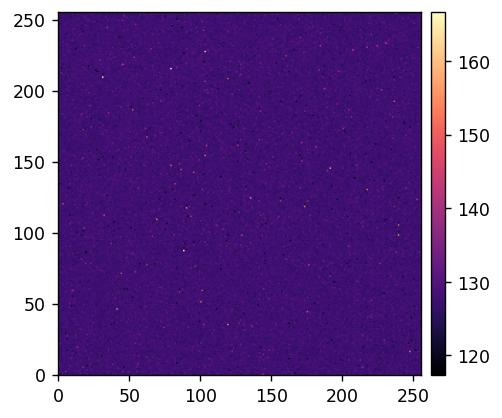

In [212]:
reload(shmim_utils)
dark_im = shmim_utils.stack(CAMSCI_STREAM, 500)
# utils.save_pickle(iefc_data_path/f'{today}_camsci_dark_frame_{im_params["texp"]:.6f}.pkl', dark_frame)

utils.imshow([dark_im])

In [213]:
reload(coro_utils)
coro_utils.move_block_out(client0)

# Use a waffle pattern to figure out the centering of the science camera images. 

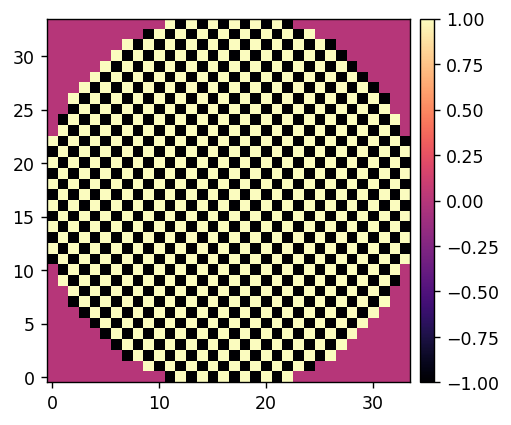

In [214]:
reload(dm)
# waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
waffle_command = dm.make_fourier_command(x_cpa=17, y_cpa=17, return_np=1) * dm_mask
utils.imshow([waffle_command])

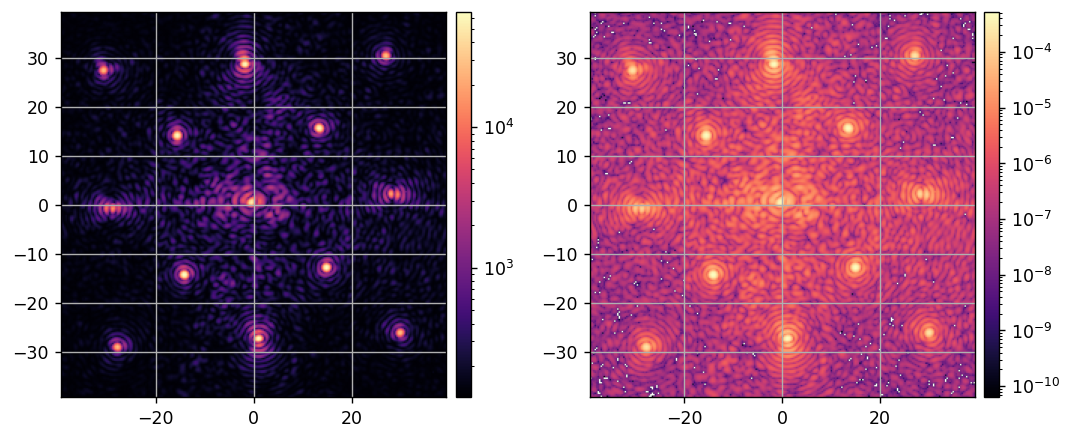

In [215]:
reload(coro_utils)
reload(shmim_utils)

coro_utils.set_dm(DM_STREAM, 20e-9 * waffle_command)
waffle_im = shmim_utils.stack(CAMSCI_STREAM, 100)
waffle_im_ni = coro_utils.normalize_coro_im(waffle_im, im_params, ref_psf_params, dark_im)
utils.imshow(
    [waffle_im, waffle_im_ni], 
    norms=[LogNorm(), LogNorm()],
    grids=2*[1], 
    pxscls=2*[camsci_pxscl_lamDc],
)

Centroids:
 [[ 81.50670831  80.85755371]
 [ 76.77657683 173.43465543]
 [171.27182941 178.32176175]
 [176.06536013  85.6436245 ]
 [ 81.50670831  80.85755371]]


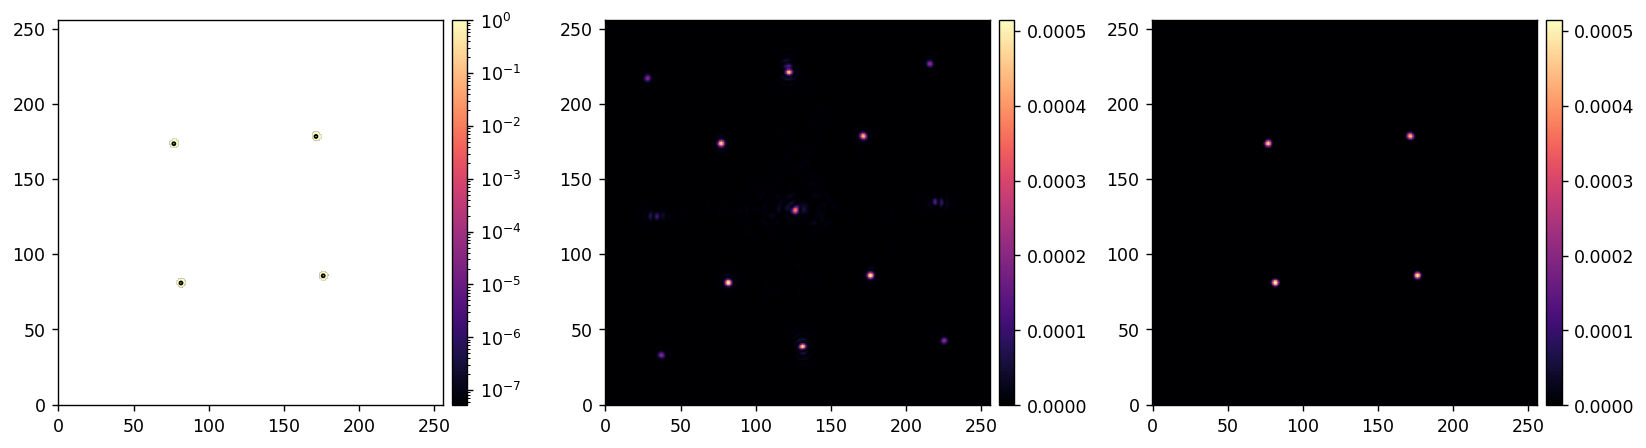

Angle:  87.0640278018694
Measured center in X:  126.3778529370914
Measured center in Y:  129.577262674771
Required shift in X:  2.0
Required shift in Y:  -2.0


In [216]:
reload(coro_utils)

xshift, yshift, angle = coro_utils.measure_waffle_center_and_angle(
    xp.array(waffle_im_ni), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-5, 
    r_thresh_min=16,
    r_thresh_max=25,
)

# Create the mask defining the dark hole region. 

1022


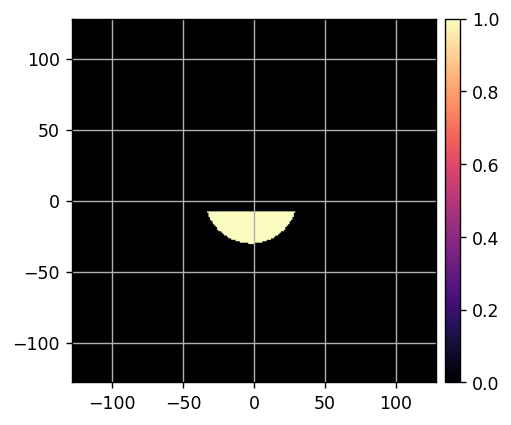

In [320]:
reload(utils)
iwa = 3
owa = 10
rotation = 90
dh_mask = utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
    return_np=1,
)
print(dh_mask.sum())
utils.imshow(
    [dh_mask],
    pxscls=[1],
    grids=[1,]
)

Ratio of pixels greater than zero versus total pixels: 1022 / 1022 = 1.00


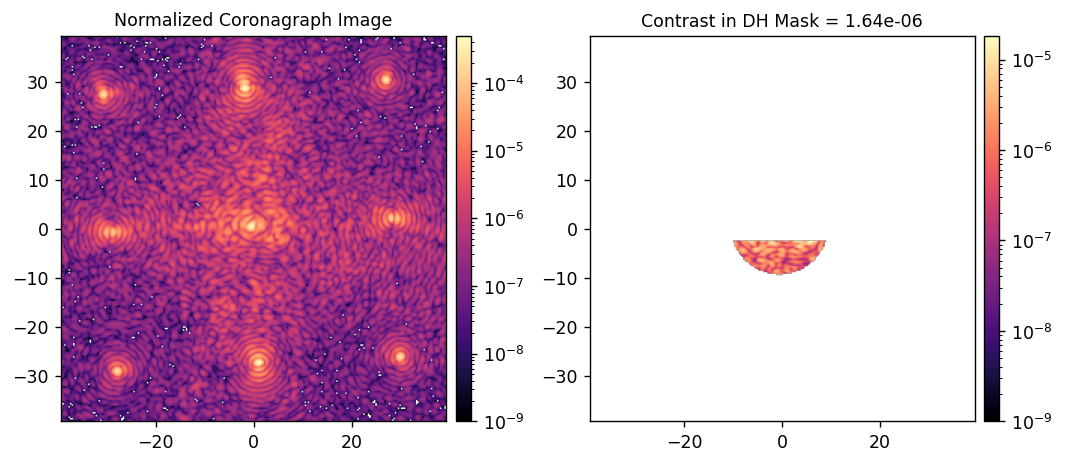

In [ ]:
reload(coro_utils)
coro_utils.zero_dm(DM_STREAM)

coro_im = np.mean(CAMSCI_STREAM.grab_many(50), axis=0)
coro_im_ni = coro_utils.normalize_coro_im(coro_im, im_params, ref_psf_params, dark_im)
contrast = coro_utils.compute_contrast(coro_im_ni, dh_mask)
utils.imshow(
    [coro_im, coro_im_ni, dh_mask * coro_im_ni],
    norms=[LogNorm(1e-10), LogNorm(1e-10)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    titles=['Normalized Coronagraph Image', f'Contrast in DH Mask = {contrast:.2e}'],
)

# Make probes and test PWP for E-field estimation.

In [ ]:
reload(utils)
reload(dm)
fourier_probes = dm.create_fourier_probes(
    dm_mask, 
    ncamsci, 
    camsci_pxscl_lamDc, 
    2,
    14, 
    rotation=90,
    use_weighting=True,
    nprobes=2,
    return_np=1, 
)

utils.imshow([fourier_probes[0], fourier_probes[1]], cmaps=3*['viridis'])

In [ ]:
DM_STREAM.write(np.zeros_like(dm_mask))


In [ ]:
reload(pwp)

current_command = DM_STREAM.grab_latest() / 1e6
current_acts = current_command[dm_mask]

E_FP_NOM = M.forward(current_acts, M.wavelength_c, use_vortex=True, return_ints=False)
utils.imshow(
    [current_command, xp.array(dh_mask)*xp.abs(E_FP_NOM)**2, xp.array(dh_mask)*xp.angle(E_FP_NOM)],
    norms=[None, LogNorm(), None],
    cmaps=['viridis', 'magma', 'twilight'],
)

E_est, E_est_vec = pwp.run(
    CAMSCI_STREAM,
    DM_STREAM,
    im_params,
    ref_psf_params,
    50, 
    dh_mask, 
    dm_mask,
    fourier_probes, 
    5e-9,
    model=M, 
    wavelength=M.wavelength,
    E_FP_NOM=E_FP_NOM,
    reg_cond=1e-3, 
    gain=1,
    plot=1,
    plot_est=1,
    delay=0.05,
)

In [316]:
coro_utils.zero_dm(DM_STREAM)
